
# Minority-Class Analysis and Controlled Balancing Notebook

This notebook is designed for your CICIoT2023 workflow.

## Goals
1. Analyze minority attack classes in detail
2. Understand how each minority class behaves through feature statistics
3. Compare minority classes against the majority classes
4. Generate controlled synthetic tabular samples for minority classes
5. Build a more balanced dataset ready for later training

## Engineering note
This notebook learns class behavior from your dataset itself:
- min / max / quantiles
- mean / std
- constant / near-constant features
- bounded perturbation around real samples

You already have useful sources in your repo, including:
- `processed/merged_full/dataset_34classes_clean.csv`
- `processed_merged_full/augmentation_controlled/dataset_34classes_augmented_controlled.csv`
- `processed/feature_analysis/class_counts_34.csv`
- `processed/feature_analysis/minority_classes_lt_*.csv` fileciteturn28file0

## Recommendation
Start from the clean 34-class dataset first, then generate a new balanced dataset in a new output folder.


In [1]:

from pathlib import Path
import json
import gc
import random
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)


In [2]:

# =========================
# Paths - edit if needed
# =========================
DATASET_PATH = Path(r"E:\dataset\processed\merged_full\dataset_34classes_clean.csv")
CLASS_COUNT_PATH = Path(r"E:\dataset\processed\feature_analysis\class_counts_34.csv")

OUTPUT_DIR = Path(r"E:\dataset\processed_merged_full\minority_balancing_v2")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LABEL_COL = "label"
DROP_DUPLICATES = True

TARGET_STRATEGY = "cap_majority"   # max / quantile / custom / cap_majority
TARGET_COUNT_CUSTOM = 300_000
TARGET_COUNT_CAP = 300_000
TARGET_QUANTILE = 0.75

AUGMENT_ONLY = True
NROWS = None


In [3]:

print("Dataset:", DATASET_PATH)
print("Output dir:", OUTPUT_DIR)

assert DATASET_PATH.exists(), f"Dataset not found: {DATASET_PATH}"

df = pd.read_csv(DATASET_PATH, nrows=NROWS)
print("Original shape:", df.shape)

if DROP_DUPLICATES:
    dup_count = int(df.duplicated().sum())
    print("Duplicate rows:", dup_count)
    if dup_count > 0:
        df = df.drop_duplicates().reset_index(drop=True)
        print("Shape after drop_duplicates:", df.shape)

assert LABEL_COL in df.columns, f"Missing label column: {LABEL_COL}"

display(df.head())
print(df.info())


Dataset: E:\dataset\processed\merged_full\dataset_34classes_clean.csv
Output dir: E:\dataset\processed_merged_full\minority_balancing_v2
Original shape: (21005617, 34)
Duplicate rows: 303622
Shape after drop_duplicates: (20701995, 34)


,Header_Length,Protocol Type,Time_To_Live,Rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,ack_count,HTTP,HTTPS,DNS,Telnet,SMTP,SSH,IRC,TCP,UDP,DHCP,ARP,ICMP,IGMP,Tot sum,Min,Max,AVG,Std,IAT,Number,Variance,label,label_id_34
0,19.92,6.0,63.36,25893.96300,0.0,0.0,0.0,0.99,0.99,0.0,99.0,0.0,0.01,0.0,0.0,0.0,0.0,0.0,0.99,0.00,0.0,0.01,0.00,0.0,6421.0,60.0,481.0,64.21,42.10000,0.000039,100.0,1772.41,DDOS-PSHACK_FLOOD,8
1,0.00,47.0,64.00,3703.84130,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.00,0.01,0.0,57320.0,98.0,578.0,573.20,48.00000,0.000271,100.0,2304.00,MIRAI-GREIP_FLOOD,23
2,7.92,17.0,65.91,19673.09600,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.99,0.0,0.00,0.01,0.0,6010.0,60.0,70.0,60.10,1.00000,0.000057,100.0,1.00,DOS-UDP_FLOOD,21
3,20.40,6.0,110.50,261.66483,0.1,0.0,0.3,0.20,0.40,0.0,4.0,0.0,0.50,0.0,0.0,0.0,0.0,0.0,0.70,0.20,0.0,0.10,0.00,0.0,2223.0,54.0,1500.0,222.30,451.59668,0.004766,10.0,203939.56,DNS_SPOOFING,17
4,0.32,1.0,63.96,28944.20000,0.0,0.0,0.0,0.00,0.01,0.0,1.0,0.0,0.01,0.0,0.0,0.0,0.0,0.0,0.01,0.00,0.0,0.00,0.99,0.0,6006.0,60.0,66.0,60.06,0.60000,0.000035,100.0,0.36,DDOS-ICMP_FLOOD,6


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20701995 entries, 0 to 20701994
Data columns (total 34 columns):
 #   Column           Dtype  
---  ------           -----  
 0   Header_Length    float64
 1   Protocol Type    float64
 2   Time_To_Live     float64
 3   Rate             float64
 4   fin_flag_number  float64
 5   syn_flag_number  float64
 6   rst_flag_number  float64
 7   psh_flag_number  float64
 8   ack_flag_number  float64
 9   ece_flag_number  float64
 10  ack_count        float64
 11  HTTP             float64
 12  HTTPS            float64
 13  DNS              float64
 14  Telnet           float64
 15  SMTP             float64
 16  SSH              float64
 17  IRC              float64
 18  TCP              float64
 19  UDP              float64
 20  DHCP             float64
 21  ARP              float64
 22  ICMP             float64
 23  IGMP             float64
 24  Tot sum          float64
 25  Min              float64
 26  Max              float64
 27  AVG       

Header_Length    0
Min              0
UDP              0
DHCP             0
ARP              0
ICMP             0
IGMP             0
Tot sum          0
Max              0
Protocol Type    0
AVG              0
Std              0
IAT              0
Number           0
Variance         0
label            0
TCP              0
IRC              0
SSH              0
SMTP             0
dtype: int64

Numeric feature count: 32
['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'ack_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP']


,label,count
0,DDOS-ICMP_FLOOD,1893583
1,DDOS-UDP_FLOOD,1876996
2,DDOS-SYN_FLOOD,1749348
3,DOS-UDP_FLOOD,1720950
4,DDOS-PSHACK_FLOOD,1637353
5,DDOS-TCP_FLOOD,1538829
6,DDOS-RSTFINFLOOD,1248655
7,DDOS-SYNONYMOUSIP_FLOOD,1166360
8,DOS-SYN_FLOOD,1133753
9,DOS-TCP_FLOOD,1112260


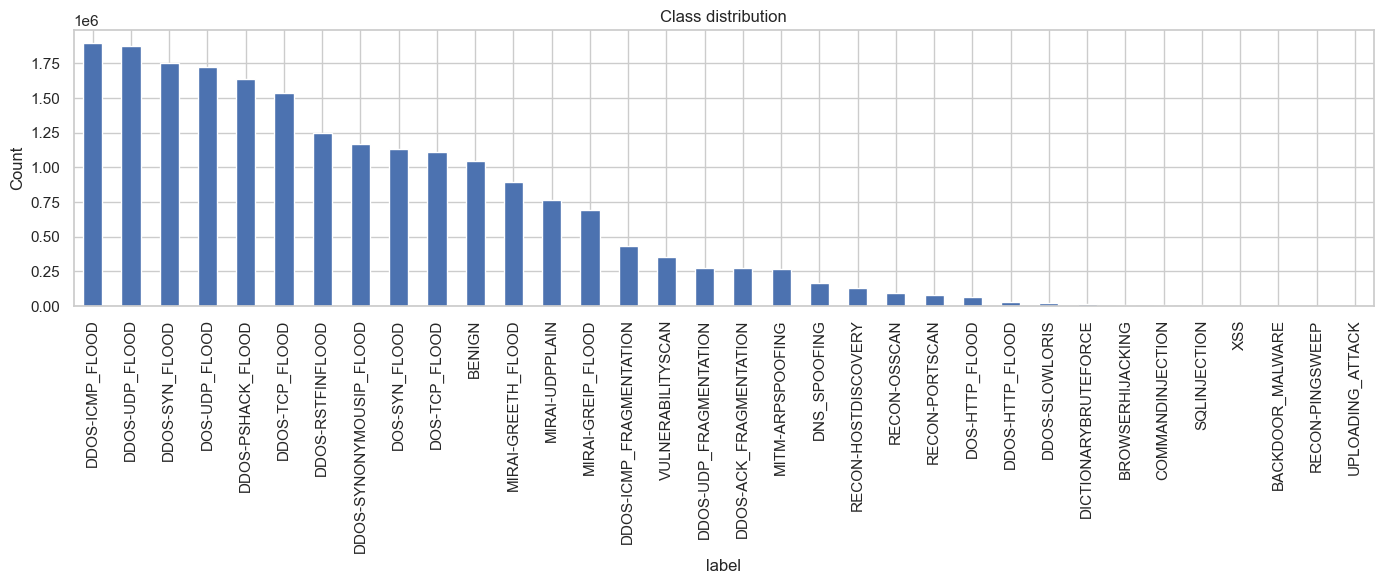

In [4]:

missing = df.isna().sum().sort_values(ascending=False)
display(missing.head(20))

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c not in ["label_id_34"]]
print("Numeric feature count:", len(feature_cols))
print(feature_cols[:20])

class_counts = df[LABEL_COL].value_counts().sort_values(ascending=False)
class_dist_df = class_counts.rename_axis("label").reset_index(name="count")
display(class_dist_df.head(20))

plt.figure(figsize=(14, 6))
class_counts.plot(kind="bar")
plt.title("Class distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [5]:

max_count = int(class_counts.max())
min_count = int(class_counts.min())
median_count = int(class_counts.median())

if TARGET_STRATEGY == "max":
    target_count = max_count
elif TARGET_STRATEGY == "quantile":
    target_count = int(class_counts.quantile(TARGET_QUANTILE))
elif TARGET_STRATEGY == "custom":
    target_count = int(TARGET_COUNT_CUSTOM)
elif TARGET_STRATEGY == "cap_majority":
    target_count = int(min(max_count, TARGET_COUNT_CAP))
else:
    raise ValueError(f"Unknown TARGET_STRATEGY: {TARGET_STRATEGY}")

print("Max count   :", max_count)
print("Median count:", median_count)
print("Min count   :", min_count)
print("Target count:", target_count)

balance_plan = class_dist_df.copy()
balance_plan["target_count"] = target_count
balance_plan["to_generate"] = (balance_plan["target_count"] - balance_plan["count"]).clip(lower=0)
balance_plan["to_drop"] = (balance_plan["count"] - balance_plan["target_count"]).clip(lower=0)

if AUGMENT_ONLY:
    balance_plan["final_count"] = np.where(
        balance_plan["count"] >= target_count,
        balance_plan["count"],
        target_count
    )
else:
    balance_plan["final_count"] = target_count

display(balance_plan.head(40))


Max count   : 1893583
Median count: 272476
Min count   : 1196
Target count: 300000


,label,count,target_count,to_generate,to_drop,final_count
0,DDOS-ICMP_FLOOD,1893583,300000,0,1593583,1893583
1,DDOS-UDP_FLOOD,1876996,300000,0,1576996,1876996
2,DDOS-SYN_FLOOD,1749348,300000,0,1449348,1749348
3,DOS-UDP_FLOOD,1720950,300000,0,1420950,1720950
4,DDOS-PSHACK_FLOOD,1637353,300000,0,1337353,1637353
5,DDOS-TCP_FLOOD,1538829,300000,0,1238829,1538829
6,DDOS-RSTFINFLOOD,1248655,300000,0,948655,1248655
7,DDOS-SYNONYMOUSIP_FLOOD,1166360,300000,0,866360,1166360
8,DOS-SYN_FLOOD,1133753,300000,0,833753,1133753
9,DOS-TCP_FLOOD,1112260,300000,0,812260,1112260


In [6]:

minority_df = balance_plan[balance_plan["count"] < target_count].copy()
majority_df = balance_plan[balance_plan["count"] >= target_count].copy()

print("Minority classes:", len(minority_df))
display(minority_df.sort_values("count").head(40))

minority_labels = minority_df["label"].tolist()


Minority classes: 18


,label,count,target_count,to_generate,to_drop,final_count
33,UPLOADING_ATTACK,1196,300000,298804,0,300000
32,RECON-PINGSWEEP,2161,300000,297839,0,300000
31,BACKDOOR_MALWARE,3075,300000,296925,0,300000
30,XSS,3705,300000,296295,0,300000
29,SQLINJECTION,5022,300000,294978,0,300000
28,COMMANDINJECTION,5150,300000,294850,0,300000
27,BROWSERHIJACKING,5560,300000,294440,0,300000
26,DICTIONARYBRUTEFORCE,12520,300000,287480,0,300000
25,DDOS-SLOWLORIS,22400,300000,277600,0,300000
24,DDOS-HTTP_FLOOD,27597,300000,272403,0,300000


In [7]:

def describe_class(df_class, feature_cols):
    desc_rows = []
    n = len(df_class)
    for col in feature_cols:
        s = df_class[col].astype(float)
        vc = s.value_counts(dropna=False, normalize=True)
        top_freq = float(vc.iloc[0]) if len(vc) else np.nan
        desc_rows.append({
            "feature": col,
            "count": n,
            "min": float(s.min()),
            "q05": float(s.quantile(0.05)),
            "median": float(s.median()),
            "mean": float(s.mean()),
            "q95": float(s.quantile(0.95)),
            "max": float(s.max()),
            "std": float(s.std(ddof=0)),
            "nonzero_ratio": float((s != 0).mean()),
            "top_value_ratio": top_freq,
            "is_constant_in_class": bool(s.nunique(dropna=False) <= 1),
            "is_near_constant_in_class": bool(top_freq >= 0.995),
        })
    return pd.DataFrame(desc_rows)

class_behavior_dir = OUTPUT_DIR / "class_behavior"
class_behavior_dir.mkdir(parents=True, exist_ok=True)

summary_rows = []

for label in minority_labels:
    df_class = df[df[LABEL_COL] == label].copy()
    desc = describe_class(df_class, feature_cols)
    desc.to_csv(class_behavior_dir / f"{label}_feature_profile.csv", index=False)

    summary_rows.append({
        "label": label,
        "count": int(len(df_class)),
        "n_constant_features": int(desc["is_constant_in_class"].sum()),
        "n_near_constant_features": int(desc["is_near_constant_in_class"].sum()),
        "mean_std_across_features": float(desc["std"].mean()),
    })

class_behavior_summary = pd.DataFrame(summary_rows).sort_values("count")
display(class_behavior_summary)
class_behavior_summary.to_csv(OUTPUT_DIR / "minority_class_behavior_summary.csv", index=False)


,label,count,n_constant_features,n_near_constant_features,mean_std_across_features
17,UPLOADING_ATTACK,1196,4,6,27477.593127
16,RECON-PINGSWEEP,2161,5,5,25908.716936
15,BACKDOOR_MALWARE,3075,4,5,52013.247748
14,XSS,3705,4,5,33463.843353
13,SQLINJECTION,5022,4,6,13622.308027
12,COMMANDINJECTION,5150,4,5,27523.264165
11,BROWSERHIJACKING,5560,5,7,27468.748361
10,DICTIONARYBRUTEFORCE,12520,3,4,23407.357398
9,DDOS-SLOWLORIS,22400,3,5,20085.631426
8,DDOS-HTTP_FLOOD,27597,3,6,7431.871357


In [8]:

reference_majority_labels = class_counts.head(5).index.tolist()
print("Reference majority labels:", reference_majority_labels)

comparison_rows = []

for min_label in minority_labels:
    df_min = df[df[LABEL_COL] == min_label]
    min_means = df_min[feature_cols].mean()

    for ref_label in reference_majority_labels:
        df_ref = df[df[LABEL_COL] == ref_label]
        ref_means = df_ref[feature_cols].mean()

        abs_diff = (min_means - ref_means).abs().sort_values(ascending=False)
        top_features = abs_diff.head(10).index.tolist()

        comparison_rows.append({
            "minority_label": min_label,
            "reference_label": ref_label,
            "top_different_features": ", ".join(top_features),
            "mean_abs_diff_top10": float(abs_diff.head(10).mean()),
        })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df.head(20))
comparison_df.to_csv(OUTPUT_DIR / "minority_vs_majority_comparisons.csv", index=False)


Reference majority labels: ['DDOS-ICMP_FLOOD', 'DDOS-UDP_FLOOD', 'DDOS-SYN_FLOOD', 'DOS-UDP_FLOOD', 'DDOS-PSHACK_FLOOD']


,minority_label,reference_label,top_different_features,mean_abs_diff_top10
0,DDOS-UDP_FRAGMENTATION,DDOS-ICMP_FLOOD,"Variance, Tot sum, Rate, Max, AVG, Std, Min, P...",46086.282473
1,DDOS-UDP_FRAGMENTATION,DDOS-UDP_FLOOD,"Variance, Tot sum, Rate, Max, AVG, Std, Min, H...",45754.387214
2,DDOS-UDP_FRAGMENTATION,DDOS-SYN_FLOOD,"Variance, Tot sum, Rate, Max, AVG, Std, Min, H...",45508.187994
3,DDOS-UDP_FRAGMENTATION,DOS-UDP_FLOOD,"Variance, Tot sum, Rate, Max, AVG, Std, Min, H...",44201.738961
4,DDOS-UDP_FRAGMENTATION,DDOS-PSHACK_FLOOD,"Variance, Tot sum, Rate, Max, AVG, Std, ack_co...",46164.882215
5,DDOS-ACK_FRAGMENTATION,DDOS-ICMP_FLOOD,"Variance, Tot sum, Rate, Max, AVG, Std, Min, a...",45846.360336
6,DDOS-ACK_FRAGMENTATION,DDOS-UDP_FLOOD,"Variance, Tot sum, Rate, Max, AVG, Std, Min, a...",45515.897174
7,DDOS-ACK_FRAGMENTATION,DDOS-SYN_FLOOD,"Variance, Tot sum, Rate, Max, AVG, Std, Min, a...",45266.894871
8,DDOS-ACK_FRAGMENTATION,DOS-UDP_FLOOD,"Variance, Tot sum, Rate, Max, AVG, Std, Min, a...",43963.086864
9,DDOS-ACK_FRAGMENTATION,DDOS-PSHACK_FLOOD,"Variance, Tot sum, Rate, Max, AVG, Std, Min, a...",45914.780996


In [9]:

class_feature_bounds = {}

for label in class_counts.index.tolist():
    df_class = df[df[LABEL_COL] == label]
    bounds = {}
    for col in feature_cols:
        s = df_class[col].astype(float)
        bounds[col] = {
            "min": float(s.min()),
            "max": float(s.max()),
            "q01": float(s.quantile(0.01)),
            "q05": float(s.quantile(0.05)),
            "q95": float(s.quantile(0.95)),
            "q99": float(s.quantile(0.99)),
            "mean": float(s.mean()),
            "std": float(s.std(ddof=0)),
            "median": float(s.median()),
        }
    class_feature_bounds[label] = bounds

with open(OUTPUT_DIR / "class_feature_bounds.json", "w", encoding="utf-8") as f:
    json.dump(class_feature_bounds, f, indent=2)

print("Saved class_feature_bounds.json")


Saved class_feature_bounds.json


In [10]:

binary_like_cols = []
integer_like_cols = []
continuous_cols = []

for col in feature_cols:
    s = df[col].dropna().astype(float)
    uniq = np.sort(s.unique())

    if len(uniq) <= 5 and set(np.round(uniq, 6)).issubset({0.0, 1.0}):
        binary_like_cols.append(col)
    elif np.allclose(s, np.round(s), atol=1e-6):
        integer_like_cols.append(col)
    else:
        continuous_cols.append(col)

print("Binary-like cols :", len(binary_like_cols))
print("Integer-like cols:", len(integer_like_cols))
print("Continuous cols  :", len(continuous_cols))


Binary-like cols : 0
Integer-like cols: 6
Continuous cols  : 26


In [11]:

def generate_synthetic_for_class(
    class_df,
    n_generate,
    feature_cols,
    bounds,
    binary_cols,
    integer_cols,
    continuous_cols,
    label_col="label",
    noise_scale_cont=0.03,
    noise_scale_int=0.02,
    preserve_near_constant=True,
    near_constant_threshold=0.995,
    seed=42,
):
    rng = np.random.default_rng(seed)

    if n_generate <= 0:
        return class_df.iloc[0:0].copy()

    class_df = class_df.reset_index(drop=True).copy()
    X = class_df[feature_cols].copy()
    synth = pd.DataFrame(index=np.arange(n_generate), columns=feature_cols, dtype=np.float32)

    near_constant_info = {}
    for col in feature_cols:
        vc = X[col].value_counts(normalize=True, dropna=False)
        if len(vc) > 0:
            top_val = vc.index[0]
            top_freq = float(vc.iloc[0])
            near_constant_info[col] = (top_val, top_freq)
        else:
            near_constant_info[col] = (0.0, 1.0)

    idx_a = rng.integers(0, len(X), size=n_generate)
    idx_b = rng.integers(0, len(X), size=n_generate)
    lam = rng.uniform(0.2, 0.8, size=n_generate).astype(np.float32)

    Xa = X.iloc[idx_a].to_numpy(dtype=np.float32)
    Xb = X.iloc[idx_b].to_numpy(dtype=np.float32)
    Xs = lam[:, None] * Xa + (1.0 - lam[:, None]) * Xb

    for j, col in enumerate(feature_cols):
        col_bounds = bounds[col]
        col_std = max(col_bounds["std"], 1e-8)

        if col in binary_cols:
            probs = rng.random(n_generate)
            Xs[:, j] = np.where(probs < 0.5, Xa[:, j], Xb[:, j])
        elif col in integer_cols:
            noise = rng.normal(0.0, noise_scale_int * col_std, size=n_generate)
            Xs[:, j] = np.round(Xs[:, j] + noise)
        else:
            noise = rng.normal(0.0, noise_scale_cont * col_std, size=n_generate)
            Xs[:, j] = Xs[:, j] + noise

        top_val, top_freq = near_constant_info[col]
        if preserve_near_constant and top_freq >= near_constant_threshold:
            mask = rng.random(n_generate) < top_freq
            Xs[mask, j] = float(top_val)

        low = col_bounds["q01"]
        high = col_bounds["q99"]
        if not np.isfinite(low) or not np.isfinite(high) or low >= high:
            low = col_bounds["min"]
            high = col_bounds["max"]

        Xs[:, j] = np.clip(Xs[:, j], low, high)

    synth[feature_cols] = Xs
    synth[label_col] = class_df[label_col].iloc[0]
    return synth


In [12]:

synthetic_parts = []
augmentation_report = []

for _, row in minority_df.iterrows():
    label = row["label"]
    current_count = int(row["count"])
    target_count_cls = int(row["target_count"])
    to_generate = int(row["to_generate"])

    print(f"Processing {label} | current={current_count:,} | target={target_count_cls:,} | generate={to_generate:,}")

    if to_generate <= 0:
        augmentation_report.append({
            "label": label,
            "original_count": current_count,
            "generated_count": 0,
            "final_target": current_count if AUGMENT_ONLY else target_count_cls,
        })
        continue

    class_df = df[df[LABEL_COL] == label].copy()
    bounds = class_feature_bounds[label]

    synth_df = generate_synthetic_for_class(
        class_df=class_df,
        n_generate=to_generate,
        feature_cols=feature_cols,
        bounds=bounds,
        binary_cols=binary_like_cols,
        integer_cols=integer_like_cols,
        continuous_cols=continuous_cols,
        label_col=LABEL_COL,
        noise_scale_cont=0.03,
        noise_scale_int=0.02,
        preserve_near_constant=True,
        near_constant_threshold=0.995,
        seed=SEED,
    )

    synthetic_parts.append(synth_df)

    augmentation_report.append({
        "label": label,
        "original_count": current_count,
        "generated_count": int(len(synth_df)),
        "final_target": target_count_cls if current_count < target_count_cls else current_count,
    })

    del class_df, synth_df
    gc.collect()

augmentation_report_df = pd.DataFrame(augmentation_report).sort_values("original_count")
display(augmentation_report_df)
augmentation_report_df.to_csv(OUTPUT_DIR / "augmentation_report_v2.csv", index=False)


Processing DDOS-UDP_FRAGMENTATION | current=273,415 | target=300,000 | generate=26,585
Processing DDOS-ACK_FRAGMENTATION | current=271,537 | target=300,000 | generate=28,463
Processing MITM-ARPSPOOFING | current=268,962 | target=300,000 | generate=31,038
Processing DNS_SPOOFING | current=166,925 | target=300,000 | generate=133,075
Processing RECON-HOSTDISCOVERY | current=127,863 | target=300,000 | generate=172,137
Processing RECON-OSSCAN | current=92,323 | target=300,000 | generate=207,677
Processing RECON-PORTSCAN | current=76,789 | target=300,000 | generate=223,211
Processing DOS-HTTP_FLOOD | current=68,445 | target=300,000 | generate=231,555
Processing DDOS-HTTP_FLOOD | current=27,597 | target=300,000 | generate=272,403
Processing DDOS-SLOWLORIS | current=22,400 | target=300,000 | generate=277,600
Processing DICTIONARYBRUTEFORCE | current=12,520 | target=300,000 | generate=287,480
Processing BROWSERHIJACKING | current=5,560 | target=300,000 | generate=294,440
Processing COMMANDINJEC

,label,original_count,generated_count,final_target
17,UPLOADING_ATTACK,1196,298804,300000
16,RECON-PINGSWEEP,2161,297839,300000
15,BACKDOOR_MALWARE,3075,296925,300000
14,XSS,3705,296295,300000
13,SQLINJECTION,5022,294978,300000
12,COMMANDINJECTION,5150,294850,300000
11,BROWSERHIJACKING,5560,294440,300000
10,DICTIONARYBRUTEFORCE,12520,287480,300000
9,DDOS-SLOWLORIS,22400,277600,300000
8,DDOS-HTTP_FLOOD,27597,272403,300000


In [13]:

synthetic_df = pd.concat(synthetic_parts, ignore_index=True) if synthetic_parts else df.iloc[0:0].copy()
print("Synthetic shape:", synthetic_df.shape)

if AUGMENT_ONLY:
    final_df = pd.concat([df, synthetic_df], ignore_index=True)
else:
    balanced_parts = []
    for _, row in balance_plan.iterrows():
        label = row["label"]
        target = int(row["target_count"])
        class_df = df[df[LABEL_COL] == label].copy()

        if len(class_df) > target:
            sampled = class_df.sample(n=target, random_state=SEED)
            balanced_parts.append(sampled)
        else:
            balanced_parts.append(class_df)

    final_df = pd.concat(balanced_parts + ([synthetic_df] if len(synthetic_df) > 0 else []), ignore_index=True)

print("Final shape:", final_df.shape)

before_counts = df[LABEL_COL].value_counts().sort_index()
after_counts = final_df[LABEL_COL].value_counts().sort_index()

before_after = pd.DataFrame({
    "before": before_counts,
    "after": after_counts,
}).fillna(0).astype(int).sort_values("after", ascending=False)

display(before_after.head(40))
before_after.to_csv(OUTPUT_DIR / "class_distribution_before_after_v2.csv")


Synthetic shape: (3965355, 33)
Final shape: (24667350, 34)


,before,after
label,,
DDOS-ICMP_FLOOD,1893583,1893583
DDOS-UDP_FLOOD,1876996,1876996
DDOS-SYN_FLOOD,1749348,1749348
DOS-UDP_FLOOD,1720950,1720950
DDOS-PSHACK_FLOOD,1637353,1637353
DDOS-TCP_FLOOD,1538829,1538829
DDOS-RSTFINFLOOD,1248655,1248655
DDOS-SYNONYMOUSIP_FLOOD,1166360,1166360
DOS-SYN_FLOOD,1133753,1133753


In [14]:

plausibility_rows = []

for label in minority_labels:
    real_df = df[df[LABEL_COL] == label]
    synth_df = synthetic_df[synthetic_df[LABEL_COL] == label]

    if len(synth_df) == 0:
        continue

    for col in feature_cols:
        plausibility_rows.append({
            "label": label,
            "feature": col,
            "real_mean": float(real_df[col].mean()),
            "synth_mean": float(synth_df[col].mean()),
            "abs_mean_diff": float(abs(real_df[col].mean() - synth_df[col].mean())),
            "real_std": float(real_df[col].std(ddof=0)),
            "synth_std": float(synth_df[col].std(ddof=0)),
            "real_min": float(real_df[col].min()),
            "synth_min": float(synth_df[col].min()),
            "real_max": float(real_df[col].max()),
            "synth_max": float(synth_df[col].max()),
        })

plausibility_df = pd.DataFrame(plausibility_rows)
display(plausibility_df.head(20))
plausibility_df.to_csv(OUTPUT_DIR / "plausibility_stats_v2.csv", index=False)


,label,feature,real_mean,synth_mean,abs_mean_diff,real_std,synth_std,real_min,synth_min,real_max,synth_max
0,DDOS-UDP_FRAGMENTATION,Header_Length,4.638671,4.626975e+00,0.011697,2.375504,1.665872e+00,0.00000,3.680000,5.212000e+01,17.799999
1,DDOS-UDP_FRAGMENTATION,Protocol Type,16.869144,1.686718e+01,0.001964,1.219156,9.278265e-01,0.00000,6.000000,1.700000e+01,17.000000
2,DDOS-UDP_FRAGMENTATION,Time_To_Live,65.850872,6.577171e+01,0.079159,7.408759,4.790946e+00,10.92000,59.369999,2.550000e+02,99.709999
3,DDOS-UDP_FRAGMENTATION,Rate,2205.825864,2.020536e+03,185.289732,16307.656161,1.263334e+03,0.00161,146.447968,3.145728e+06,7655.158203
4,DDOS-UDP_FRAGMENTATION,fin_flag_number,0.001297,1.245819e-03,0.000051,0.005354,3.233785e-03,0.00000,0.000000,5.000000e-01,0.020000
5,DDOS-UDP_FRAGMENTATION,syn_flag_number,0.005195,5.162035e-03,0.000033,0.012733,8.696053e-03,0.00000,0.000000,5.000000e-01,0.060000
6,DDOS-UDP_FRAGMENTATION,rst_flag_number,0.000958,8.812445e-04,0.000076,0.006360,2.946314e-03,0.00000,0.000000,4.600000e-01,0.020000
7,DDOS-UDP_FRAGMENTATION,psh_flag_number,0.007134,6.934069e-03,0.000200,0.028410,1.751807e-02,0.00000,0.000000,8.200000e-01,0.140000
8,DDOS-UDP_FRAGMENTATION,ack_flag_number,0.021840,2.147278e-02,0.000367,0.081421,5.569904e-02,0.00000,0.000000,1.000000e+00,0.460000
9,DDOS-UDP_FRAGMENTATION,ece_flag_number,0.000134,1.398810e-04,0.000006,0.001521,8.800216e-04,0.00000,0.000000,2.500000e-01,0.010000


In [15]:

final_csv_path = OUTPUT_DIR / "dataset_34classes_balanced_v2.csv"
synthetic_csv_path = OUTPUT_DIR / "synthetic_only_v2.csv"

final_df.to_csv(final_csv_path, index=False)
synthetic_df.to_csv(synthetic_csv_path, index=False)

summary = {
    "dataset_path": str(DATASET_PATH),
    "output_dir": str(OUTPUT_DIR),
    "n_rows_original": int(len(df)),
    "n_rows_synthetic": int(len(synthetic_df)),
    "n_rows_final": int(len(final_df)),
    "n_features": int(len(feature_cols)),
    "target_strategy": TARGET_STRATEGY,
    "target_count": int(target_count),
    "augment_only": bool(AUGMENT_ONLY),
    "minority_class_count": int(len(minority_labels)),
}

with open(OUTPUT_DIR / "balancing_summary_v2.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("Saved:")
print("-", final_csv_path)
print("-", synthetic_csv_path)
print("-", OUTPUT_DIR / "augmentation_report_v2.csv")
print("-", OUTPUT_DIR / "class_distribution_before_after_v2.csv")
print("-", OUTPUT_DIR / "plausibility_stats_v2.csv")
print("-", OUTPUT_DIR / "balancing_summary_v2.json")


Saved:
- E:\dataset\processed_merged_full\minority_balancing_v2\dataset_34classes_balanced_v2.csv
- E:\dataset\processed_merged_full\minority_balancing_v2\synthetic_only_v2.csv
- E:\dataset\processed_merged_full\minority_balancing_v2\augmentation_report_v2.csv
- E:\dataset\processed_merged_full\minority_balancing_v2\class_distribution_before_after_v2.csv
- E:\dataset\processed_merged_full\minority_balancing_v2\plausibility_stats_v2.csv
- E:\dataset\processed_merged_full\minority_balancing_v2\balancing_summary_v2.json



## Final recommendation

Run this notebook first with:
- `TARGET_STRATEGY = "cap_majority"`
- `TARGET_COUNT_CAP = 300_000`
- `AUGMENT_ONLY = True`

That gives you a stronger and more practical balance without exploding disk usage.

If the generated data looks realistic, then you can try higher caps for selected classes only.
